In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import GroupKFold


from src.dataset import PatchGridDataset, PatchDataset
from src.histology_feature_extractor import extract_features
from src.train_test import train_fusion, test_fusion, test_fusion_MIL
from utils.metrics import get_metrics
from utils.set_seed import seed_everything
from utils.load_model import load_histo_model

seed = 123
seed_everything(seed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## 1. load pre-trained model and transformer

In [2]:
pretrained_model_name = ['uni', 'musk', 'phikon-v2', 'plip'][2]
pre_model, transform = load_histo_model(pretrained_model_name, device, ckpts_dir='./assets/ckpts')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## 2. Prepare Dataset

### 2.1. Load data

In [3]:
dataset_path = "/path/to/UPMC_HE"  # TODO: path to UPMC_HE image directory
label_csv = "/path/to/upmc_labels.csv"  # TODO: path to upmc_labels.csv
patient_info_csv = "/path/to/region_id_mapping.csv"  # TODO: path to region_id_mapping.csv
label_name = 'primary_outcome'
anno_label = 'cluster'
PATCH_R = 200
PATCH_SIZE = PATCH_R * 2

label_df = pd.read_csv(label_csv)[['region_id', label_name]]
patient_info_df = pd.read_csv(patient_info_csv)[['ACQUISITION_ID', 'PATIENT_ID']]
df_merge = pd.merge(label_df, patient_info_df, left_on="region_id", right_on="ACQUISITION_ID", how="inner")
df_merge = df_merge.drop(columns=["ACQUISITION_ID"]).set_index("region_id", inplace=False)

data_names = []
for name in os.listdir(dataset_path):
    if name in df_merge.index:
        if os.path.isdir(os.path.join(dataset_path, name, "he_img")):
            data_names.append(name)
data_names = np.array(data_names)

print(f'Sample amount: {len(data_names)}')

Sample amount: 283


### 2.2. Group K-Fold Data Split (by Patient)

In [ ]:
# # Order regions to ensure consistent split
# data_names = np.sort(data_names)
# np.random.shuffle(data_names)

# n_splits = 4
# patient_ids = [df_merge.loc[name, 'PATIENT_ID'] for name in data_names]
# groups = np.array(patient_ids)  # Patient groups
# split_indices = {
#     fold: (data_names[train_idx].tolist(), data_names[test_idx].tolist()) 
#     for fold, (train_idx, test_idx) in
#     enumerate(GroupKFold(n_splits=n_splits).split(data_names, groups=groups))}


with open('./data/upmc_split_indices.json', 'r') as f:
    split_indices = json.load(f)

##  3. Train and test fusion model (HOPE)

In [ ]:
results_subfolder = f"UPMC_HOPE_{pretrained_model_name}"
models_dir = f'./assets/models/{results_subfolder}'
results_dir = f'./results/{results_subfolder}'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)
print(f'Foundation model is {pretrained_model_name}.')

# Training hyperparameters
adam_epochs = 0           # Number of epochs using Adam optimizer
adam_lr = 0.01            # Learning rate for Adam optimizer
lbfgs_epochs = 1          # Number of epochs using L-BFGS optimizer
lbfgs_lr = 1              # Learning rate for L-BFGS optimizer
use_bn = True             # Whether to use batch normalization
temperature = False       # Whether to add learnable temperature parameter


patient_eval_results_all = []
test_patch_results_all = []
for fold, (train_idx, test_idx) in split_indices.items():
    seed_everything(seed)

    anno_csv = f"upmc_microE_anno_primary_outcome_patientGrp{fold}.csv"
    anno_df = pd.read_csv(os.path.join('./data/microE_annotations', anno_csv)).set_index('region_id', inplace=False)

    # Ensure no data leakage: microE annotations constructed exclusively from training set
    assert set(train_idx) == set(anno_df.index)

    train_df_merge = df_merge.loc[train_idx]
    train_df_merge = pd.merge(train_df_merge, anno_df, left_index=True, right_index=True, how="inner")
    print(f"\nFold {fold}: There are {len(train_df_merge)} patches for training.")

    # Training dataset
    zipped_crop_ranges = list(zip(train_df_merge['centerX'].values - PATCH_R, train_df_merge['centerY'].values - PATCH_R,\
                                train_df_merge['centerX'].values + PATCH_R, train_df_merge['centerY'].values + PATCH_R))
    train_crop_ranges = np.array([list(item) for item in zipped_crop_ranges])

    train_dataset = PatchDataset(img_names=train_df_merge.index.to_numpy(), 
                                target_labels=train_df_merge[label_name].to_numpy(),
                                aux_labels=train_df_merge[anno_label].to_numpy(),  # microE annotations
                                transform=transform, 
                                dataset_dir=dataset_path,
                                is_crop=True, 
                                crop_range=train_crop_ranges,
                                return_region=False)
    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8)
    train_features = extract_features(pre_model, pretrained_model_name, train_dataloader, device=device)
    train_feats = train_features['embeddings']
    train_aux_labels = train_features['aux_labels']
    train_targets = train_features['labels']

    # Train
    fusion_model = train_fusion(train_feats, train_aux_labels, train_targets, device, 
                                adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_lr=adam_lr, lbfgs_lr=lbfgs_lr,
                                use_bn=use_bn, temperature=temperature)

    torch.save(fusion_model, f'{models_dir}/fusion_model_fold{fold}.pth')

    # Test
    test_targets_true = []
    test_targets_pred = []
    test_targets_prob = []
    test_results = []

    test_df_merge = df_merge.loc[test_idx]
    for test_name, test_info in tqdm(test_df_merge.iterrows(), total=len(test_df_merge), desc='Testing'):
        test_label = test_info[label_name]
        test_dataset = PatchGridDataset(img_names=[test_name], 
                                        patch_size=PATCH_SIZE, 
                                        stride=PATCH_SIZE, 
                                        target_labels=[test_label],
                                        transform=transform, 
                                        dataset_dir=dataset_path,
                                        return_region=True)
        test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=8)
        test_features = extract_features(pre_model, pretrained_model_name, test_dataloader, device=device, show_progress=False)
        test_feats = test_features['embeddings']
        test_labels = test_features['labels']
        test_regions = test_features['regions']

        # ROI-level test
        target_pred, target_prob, target_probs, aux_probs = test_fusion_MIL(test_feats, fusion_model, device)

        test_targets_true.append(test_label)
        test_targets_prob.append(target_prob)
        test_targets_pred.append(target_pred)

        test_aux_counts = [0] * aux_probs.shape[1]
        aux_preds = np.argmax(aux_probs, axis=1)
        for pred in aux_preds:
            test_aux_counts[pred] += 1
        mean_aux_probs = np.mean(aux_probs, axis=0)
        assert len(test_aux_counts) == len(mean_aux_probs)
        for idx, (aux_count, aux_prob) in enumerate(zip(test_aux_counts, mean_aux_probs)):
            test_results.append({'sample': test_name,
                                'target_label': test_label,
                                'target_pred': target_pred,
                                'target_prob': target_prob,
                                'microE_label': idx,
                                'microE_count': aux_count,
                                'microE_prob': aux_prob})   

        # Patch-level test
        patch_target_preds, patch_target_probs, patch_aux_preds, patch_aux_probs = test_fusion(test_feats, fusion_model, device)
        for p_region, p_pred, p_prob, p_aux_pred, p_aux_prob in zip(
            test_regions, patch_target_preds, patch_target_probs, patch_aux_preds, patch_aux_probs):
            test_patch_results_all.append({'sample': test_name,
                                       'patch_region': p_region,
                                       'target_label': test_label,
                                       'target_pred': p_pred,
                                       'target_prob': p_prob,
                                       'microE_pred': p_aux_pred,
                                       'microE_probs': p_aux_prob,
                                       'test_fold': fold}) 
    
    fusion_model.to('cpu')
    del fusion_model
    torch.cuda.empty_cache()


    # Record results
    patient_eval_result = get_metrics(test_targets_true, test_targets_pred, test_targets_prob, get_report=True)
    patient_eval_result["fold"] = fold
    patient_eval_results_all.append(patient_eval_result)

    patient_eval_results_df = pd.DataFrame([patient_eval_result])
    patient_eval_results_df.to_csv(f"{results_dir}/UPMC_{label_name}_patient{fold}_target_results.csv", index=False)
    print(f"Fold{fold}: auroc = {patient_eval_result['auroc']:.3f}")

    test_aux_df = pd.DataFrame(test_results)
    test_aux_df.to_csv(f'{results_dir}/UPMC_{label_name}_patient{fold}_microE_results.csv', index=False)


print(f"\nAverage results: auroc = {pd.DataFrame(patient_eval_results_all)['auroc'].mean():.3f}")

test_patch_results_all_df = pd.DataFrame(test_patch_results_all)
test_patch_results_all_df.to_csv(f'{results_dir}/UPMC_{label_name}_ALL_patch_results.csv', index=False)


Foundation model is phikon-v2.

Fold 0: There are 32767 patches for training.


extracting features: 100%|██████████| 2048/2048 [08:40<00:00,  3.93it/s]


[L-BFGS] Train Epoch: 1 	 Aux Loss: 1.751648, Target Loss: 0.681009, Total Loss: 2.468992


Testing: 100%|██████████| 71/71 [01:32<00:00,  1.30s/it]


Fold0: auroc = 0.895

Fold 1: There are 32766 patches for training.


...

Fold2: auroc = 0.856

Fold 3: There are 32767 patches for training.


extracting features: 100%|██████████| 2048/2048 [05:53<00:00,  5.80it/s]


[L-BFGS] Train Epoch: 1 	 Aux Loss: 1.843386, Target Loss: 0.632625, Total Loss: 2.504092


Testing: 100%|██████████| 70/70 [01:17<00:00,  1.10s/it]


Fold3: auroc = 0.779

Average results: auroc = 0.792


## 4. Results Analysis

### 4.1.  Kaplan–Meier (KM) stratification by predicted TME cluster abundance

Amount of patients: 20


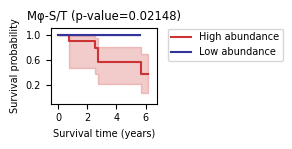

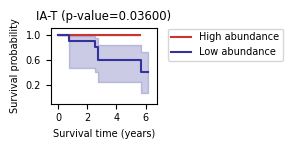

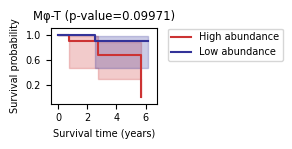

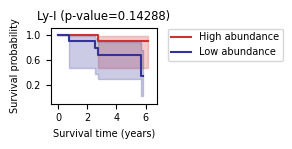

In [6]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

rcParams.update({"font.size": 7})
all_clusters = [str(i) for i in range(15)]
microE_clusters = {'2': 'Mφ-S/T',
                   '3': 'IA-T',
                   '5': 'Mφ-T',
                   '9': 'Ly-I'}
YEARS = 6
metadata_df = pd.read_csv(label_csv)[['region_id', 'primary_outcome', 'status', 'survival_day']]
patient_df = pd.read_csv(patient_info_csv)[['ACQUISITION_ID', 'PATIENT_ID']]
metadata_df = pd.merge(metadata_df, patient_df, how='left', left_on='region_id', right_on='ACQUISITION_ID')


data_path = "./results/UPMC_HOPE_phikon-v2/UPMC_primary_outcome_patient0_microE_results.csv"
df = pd.read_csv(data_path)
df = (df.pivot_table(index=['sample', 'target_prob'], 
                          columns='microE_label', 
                          values='microE_count',
                          aggfunc='first')
      .reset_index()
      .rename_axis(None, axis=1)
      .rename(columns=str))
merge_df = pd.merge(df, metadata_df, how='inner', left_on='sample', right_on='region_id')
df_summed = merge_df.groupby('PATIENT_ID').agg(
    **{col: (col, 'sum') for col in all_clusters},
    primary_outcome=('primary_outcome', 'first'),
    status=('status', 'first'),
    survival_day=('survival_day', 'first'),
    target_prob=('target_prob', 'first')
).reset_index()
df = df_summed
df['survival_year'] = df['survival_day'] / 365

print(f'Amount of patients: {len(df)}')


for cluster, cluster_name in microE_clusters.items():
    df['ratio'] = df[cluster] / df[all_clusters].sum(axis=1)
    median_ratio = df['ratio'].median()
    high_level = df[df['ratio'] > median_ratio]
    low_level = df[df['ratio'] <= median_ratio]

    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    kmf_high.fit(durations=high_level['survival_year'], event_observed=1 - high_level['primary_outcome'], label='High abundance')
    kmf_low.fit(durations=low_level['survival_year'], event_observed=1 - low_level['primary_outcome'], label='Low abundance')
    
    plt.figure(figsize=(3, 1.5))
    kmf_high.plot(color=(0.8, 0.2, 0.2))
    kmf_low.plot(color=(0.2, 0.2, 0.6))

    # TODO not sure here!!!
    statistic = logrank_test(high_level['survival_year'], low_level['survival_year'], 1 - high_level['primary_outcome'], 1 - low_level['primary_outcome'])

    plt.xlabel('Survival time (years)')
    plt.xticks([i for i in range(YEARS + 1) if (i % 2 == 0)])
    plt.xlim((-0.5, YEARS + 0.8))
    plt.ylabel('Survival probability')
    plt.yticks([0.2, 0.6, 1.0])
    plt.ylim((-0.1, 1.1))
    plt.title(f'{cluster_name} (p-value={statistic.p_value:.5f})')
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc=3)
    plt.tight_layout()
    plt.show()

### 4.2.  Spatial distribution of TME clusters predicted from H&E images

2688 3024


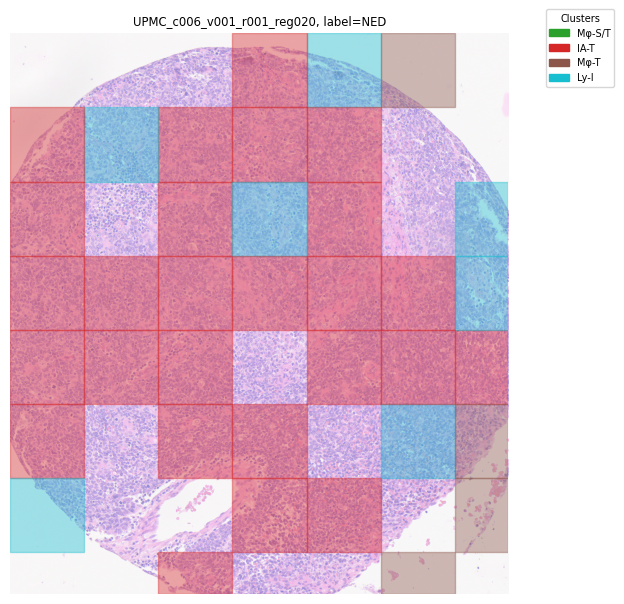

2688 2016


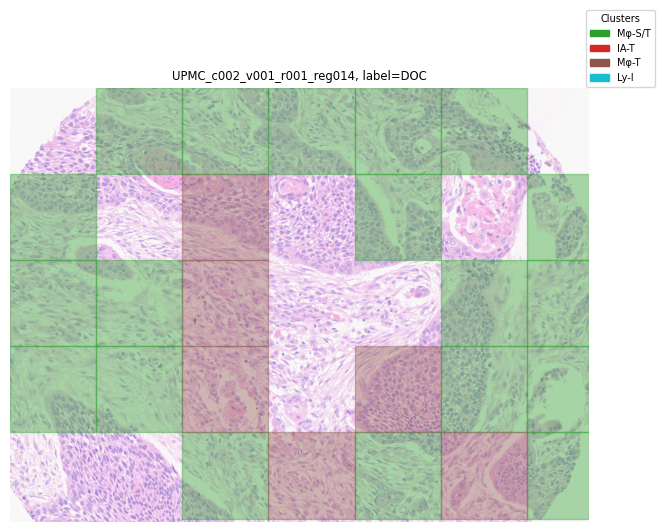

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import zarr


region_ids = ["UPMC_c006_v001_r001_reg020", "UPMC_c002_v001_r001_reg014"]
microE_clusters = {2: 'Mφ-S/T',
                   3: 'IA-T',
                   5: 'Mφ-T',
                   9: 'Ly-I'}
cmap = plt.get_cmap('tab10')


anno_df_path = "./results/UPMC_HOPE_phikon-v2/UPMC_primary_outcome_ALL_patch_results.csv"
anno_df = pd.read_csv(anno_df_path, dtype={'microE_pred': int, 'test_fold': int})
anno_df = anno_df[anno_df['test_fold'] == 0]
metadata_df = pd.read_csv(label_csv)[['region_id', 'primary_outcome', 'status']]


for region_id in region_ids:
    region_anno_df = anno_df.copy()
    region_anno_df = region_anno_df[region_anno_df['sample'] == region_id]
    region_anno_df['patch_region'] = region_anno_df['patch_region'].apply(lambda x: [int(y) for y in x[1:-1].split(' ') if len(y.strip()) > 0])

    fig, ax = plt.subplots(figsize=(6, 6))

    # H&E image
    img_region_path = f"{dataset_path}/{region_id}"
    if img_region_path[-3:] == 'png':
        img_he = Image.open(img_region_path)
    else:
        img_he_path = os.path.join(img_region_path, 'he_img')
        img_he = np.array(zarr.open(img_he_path, mode='r'))
        if img_he.shape[0] == 3:
            img_he = np.transpose(img_he, (1, 2, 0))
        img_he = Image.fromarray(img_he)
    print(img_he.width, img_he.height)
    ax.imshow(img_he, alpha=0.5, extent=[0, img_he.width, 0, img_he.height])

    # Patch results
    for index, row in region_anno_df.iterrows():
        left, top, right, bottom = row['patch_region']

        category = int(row['microE_pred'])
        if category not in microE_clusters.keys():
            continue
        else:
            color = cmap(category)

        rect = patches.Rectangle((left, img_he.height - bottom), right - left, bottom - top, linewidth=1, 
                                 edgecolor=color, facecolor=color, alpha=0.4)
        ax.add_patch(rect)


    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f"{region_id}, label={metadata_df[metadata_df['region_id'] == region_id]['status'].values[0]}")
    ax.axis('off')

    # Legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=cmap(i)) for i in microE_clusters.keys()]
    fig.legend(handles, microE_clusters.values(), title='Clusters', loc='upper right', bbox_to_anchor=(1.1, 1))

    plt.tight_layout()
    plt.show()
